# 02 — MediaPipe Test

## What this notebook does
Tests that MediaPipe can detect a hand from a single ASL Alphabet image and extract 21 landmarks (63 numbers).

## Why we do this before anything else
MediaPipe is the engine that powers the entire project. Before we loop over 87,000 images or open a live camera, we need to confirm it works on just one image first.

If MediaPipe can't find a hand in a clean studio photo, it won't work on a live camera either. We test in isolation before we build anything on top of it.

## What success looks like
- Image displays with dots and lines drawn on each finger joint
- 63 numbers get printed (x, y, z for each of 21 hand keypoints)

In [5]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import os

In [6]:
model_path = 'hand_landmarker.task'

if not os.path.exists(model_path):
    print("Downloading hand landmarker model...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task",
        model_path
    )
    print("✅ Model downloaded")
else:
    print("✅ Model already exists")

✅ Model downloaded


## Step 1 — Load one image

We grab a single image from the ASL Alphabet dataset. Nothing fancy yet — just making sure we can read the file and display it correctly.

> **Note:** cv2 reads images in BGR colour order but matplotlib expects RGB. That's why we convert with `cv2.cvtColor` before displaying. Without this the image will look blue-tinted.

Image shape: (200, 200, 3)


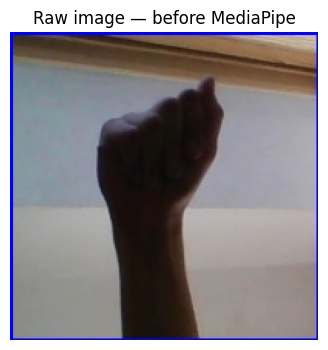

In [7]:
img_path = '../data/raw/asl_alphabet/asl_alphabet_train/A/A1.jpg'

img     = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Image shape:", img.shape)

plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.title("Raw image — before MediaPipe")
plt.axis('off')
plt.show()

## Step 2 — Run MediaPipe on the image

MediaPipe's `Hands` model scans the image and tries to find a hand. We use `static_image_mode=True` here because we're processing a single photo, not a video stream.

When we move to live camera later we'll switch this to `False` for better performance.

**What MediaPipe gives back:**
- `results.multi_hand_landmarks` — a list of detected hands
- Each hand has 21 landmarks
- Each landmark has x, y, z values (relative to image size, so values are between 0 and 1)

In [8]:
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.5
)

with vision.HandLandmarker.create_from_options(options) as landmarker:
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results = landmarker.detect(mp_image)

if results.hand_landmarks:
    print(f"✅ Hand detected — found {len(results.hand_landmarks)} hand(s)")
else:
    print("❌ No hand detected — try a different image")

✅ Hand detected — found 1 hand(s)


## Step 3 — Draw landmarks on the image

MediaPipe gives us 21 points. `draw_landmarks` draws dots on each joint and lines connecting them — this is just for us to visually confirm the detection looks correct.

You should see a skeleton drawn over the hand.

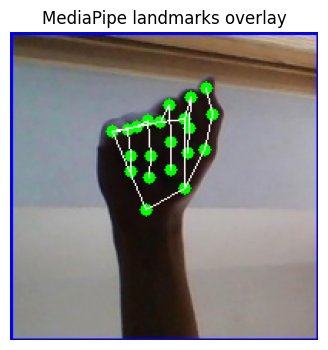

In [9]:
img_copy = img_rgb.copy()

if results.hand_landmarks:
    h, w, _ = img_copy.shape
    for hand in results.hand_landmarks:
        for lm in hand:
            cx, cy = int(lm.x * w), int(lm.y * h)
            cv2.circle(img_copy, (cx, cy), 4, (0, 255, 0), -1)
        # Draw connections
        connections = mp.tasks.vision.HandLandmarksConnections.HAND_CONNECTIONS
        for conn in connections:
            a = hand[conn.start]
            b = hand[conn.end]
            pt1 = (int(a.x * w), int(a.y * h))
            pt2 = (int(b.x * w), int(b.y * h))
            cv2.line(img_copy, pt1, pt2, (255, 255, 255), 1)

plt.figure(figsize=(4, 4))
plt.imshow(img_copy)
plt.title("MediaPipe landmarks overlay")
plt.axis('off')
plt.show()

## Step 4 — Extract the 63 numbers

This is the most important step. We pull out the raw x, y, z values from each of the 21 landmarks — that gives us 63 numbers total.

These 63 numbers are what we will train the model on — not the raw image, not the pixels, just these numbers. They describe the **shape and geometry** of the hand regardless of lighting, background, or skin tone.

```
21 landmarks × 3 values (x, y, z) = 63 numbers
```

In [10]:
if results.hand_landmarks:
    landmarks = []
    for lm in results.hand_landmarks[0]:
        landmarks.extend([lm.x, lm.y, lm.z])

    print(f"Total values extracted: {len(landmarks)}")
    print(f"\nFirst 9 values — (x, y, z) for landmark points 0, 1, 2:")
    print(np.round(landmarks[:9], 4))
    print(f"\nAll 63 values:")
    print(np.round(landmarks, 4))

Total values extracted: 63

First 9 values — (x, y, z) for landmark points 0, 1, 2:
[ 0.4412  0.5799 -0.      0.5652  0.509  -0.03    0.6342  0.3834 -0.0417]

All 63 values:
[ 0.4412  0.5799 -0.      0.5652  0.509  -0.03    0.6342  0.3834 -0.0417
  0.6565  0.2693 -0.0575  0.638   0.1818 -0.0673  0.5685  0.2846 -0.0008
  0.586   0.2149 -0.0728  0.5842  0.3144 -0.1174  0.5791  0.394  -0.1342
  0.4879  0.2902 -0.0099  0.5197  0.2376 -0.0949  0.525   0.3588 -0.1251
  0.5203  0.4455 -0.1257  0.41    0.3063 -0.0288  0.4479  0.2881 -0.1144
  0.4572  0.403  -0.1097  0.4534  0.475  -0.0816  0.3304  0.324  -0.0498
  0.3812  0.3172 -0.1052  0.392   0.4005 -0.0958  0.3937  0.4532 -0.0727]


## Step 5 — Visualise the 21 landmark positions

Let's see exactly where each numbered point sits on the hand. This helps us understand what we're working with — which numbers correspond to fingertips, knuckles, and the wrist.

- Point 0 = wrist
- Points 1–4 = thumb (base to tip)
- Points 5–8 = index finger (base to tip)
- Points 9–12 = middle finger
- Points 13–16 = ring finger
- Points 17–20 = pinky

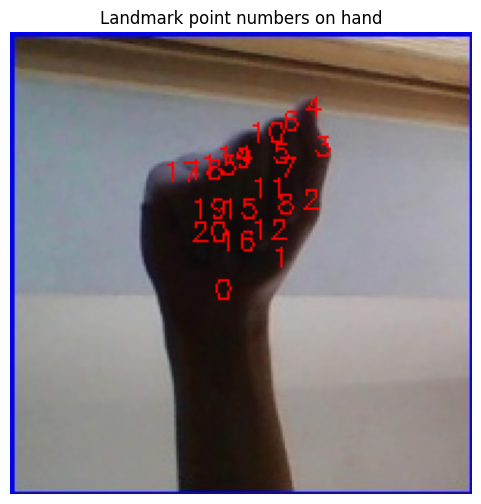

In [11]:
if results.hand_landmarks:
    h, w, _ = img_rgb.shape
    img_numbered = img_rgb.copy()

    for idx, lm in enumerate(results.hand_landmarks[0]):
        cx = int(lm.x * w)
        cy = int(lm.y * h)
        cv2.putText(img_numbered, str(idx), (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_numbered)
    plt.title("Landmark point numbers on hand")
    plt.axis('off')
    plt.show()

## ✅ Notebook complete

**What we confirmed:**
- MediaPipe can detect a hand from an ASL Alphabet image
- It gives us 21 landmarks = 63 numbers (x, y, z per point)
- The landmarks sit correctly on the finger joints

**What's next:**
Open `03_extract_landmarks.ipynb` — we'll loop this same process over all 87,000 images in the dataset and save the results to a CSV. That CSV becomes our actual training data.

Read `docs/03_extract_landmarks.md` before opening the next notebook.